In [1]:
!pip install transformers datasets seqeval evaluate -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.6/43.6 kB 1.6 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 5.9 MB/s eta 0:00:00


In [2]:
!pip install "datasets<3.0.0" -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.3/527.3 kB 10.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 177.6/177.6 kB 15.4 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2024.6.1 which is incompatible.


In [3]:
import numpy as np
import pandas as pd
import torch
import warnings
import matplotlib.pyplot as plt
import seaborn as sns
warnings.filterwarnings('ignore')

from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForTokenClassification,
    TrainingArguments,
    Trainer,
    DataCollatorForTokenClassification
)
import evaluate

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
MODEL_NAME = 'distilbert-base-uncased'

print(f"✅ Device: {device}")
print(f"✅ Model : {MODEL_NAME}")

✅ Device: cpu
✅ Model : distilbert-base-uncased


In [5]:
from datasets import load_dataset

raw_dataset = load_dataset("conll2003", trust_remote_code=True)

POS_LABELS   = raw_dataset['train'].features['pos_tags'].feature.names
CHUNK_LABELS = raw_dataset['train'].features['chunk_tags'].feature.names

print("Done.")
print("Train:", len(raw_dataset['train']))
print("Val:  ", len(raw_dataset['validation']))
print("Test: ", len(raw_dataset['test']))
print("POS labels:", len(POS_LABELS))
print("Chunk labels:", len(CHUNK_LABELS))
print(POS_LABELS)
print(CHUNK_LABELS)

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Done.
Train: 14041
Val:   3250
Test:  3453
POS labels: 47
Chunk labels: 23
['"', "''", '#', '$', '(', ')', ',', '.', ':', '``', 'CC', 'CD', 'DT', 'EX', 'FW', 'IN', 'JJ', 'JJR', 'JJS', 'LS', 'MD', 'NN', 'NNP', 'NNPS', 'NNS', 'NN|SYM', 'PDT', 'POS', 'PRP', 'PRP$', 'RB', 'RBR', 'RBS', 'RP', 'SYM', 'TO', 'UH', 'VB', 'VBD', 'VBG', 'VBN', 'VBP', 'VBZ', 'WDT', 'WP', 'WP$', 'WRB']
['O', 'B-ADJP', 'I-ADJP', 'B-ADVP', 'I-ADVP', 'B-CONJP', 'I-CONJP', 'B-INTJ', 'I-INTJ', 'B-LST', 'I-LST', 'B-NP', 'I-NP', 'B-PP', 'I-PP', 'B-PRT', 'I-PRT', 'B-SBAR', 'I-SBAR', 'B-UCP', 'I-UCP', 'B-VP', 'I-VP']


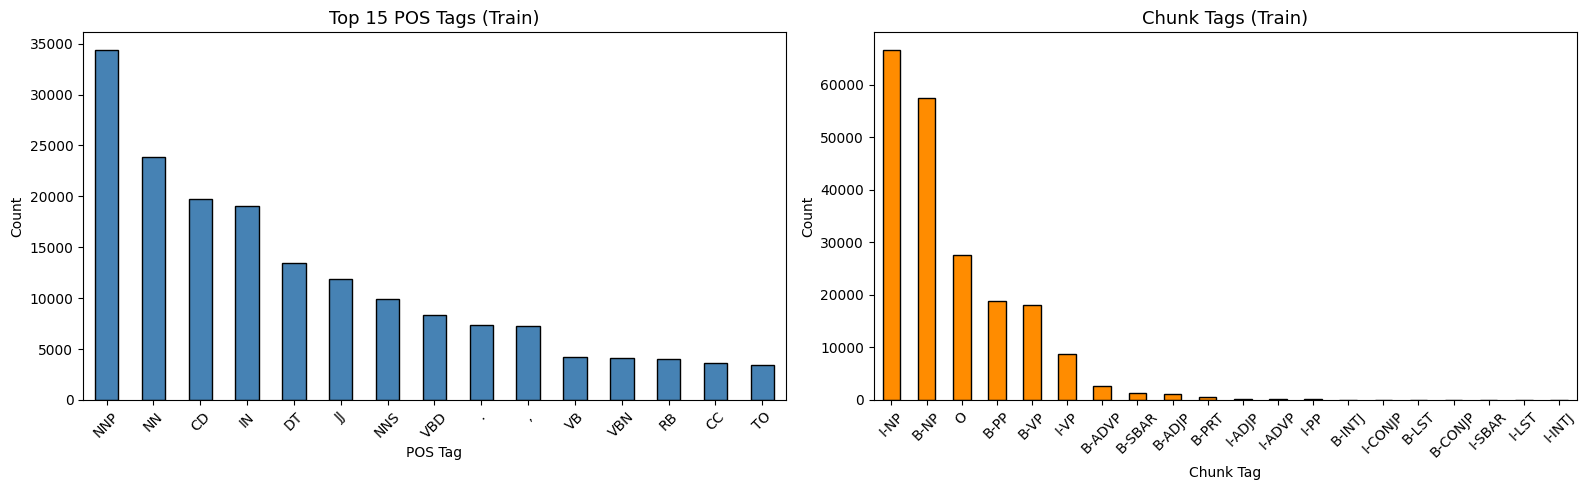


📌 Sample sentence:
  Token POS Chunk
     EU NNP  B-NP
rejects VBZ  B-VP
 German  JJ  B-NP
   call  NN  I-NP
     to  TO  B-VP
boycott  VB  I-VP
British  JJ  B-NP
   lamb  NN  I-NP
      .   .     O


In [6]:
# Visualize label distributions
train_data = raw_dataset['train']

# Flatten all POS tags
all_pos   = [tag for sent in train_data['pos_tags']   for tag in sent]
all_chunk = [tag for sent in train_data['chunk_tags'] for tag in sent]

pos_counts   = pd.Series([POS_LABELS[t]   for t in all_pos]).value_counts()[:15]
chunk_counts = pd.Series([CHUNK_LABELS[t] for t in all_chunk]).value_counts()

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pos_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Top 15 POS Tags (Train)', fontsize=13)
axes[0].set_xlabel('POS Tag')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

chunk_counts.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='black')
axes[1].set_title('Chunk Tags (Train)', fontsize=13)
axes[1].set_xlabel('Chunk Tag')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('label_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

# Show a sample sentence with all labels
sample = train_data[0]
print("\n📌 Sample sentence:")
df_sample = pd.DataFrame({
    'Token': sample['tokens'],
    'POS':   [POS_LABELS[t]   for t in sample['pos_tags']],
    'Chunk': [CHUNK_LABELS[t] for t in sample['chunk_tags']]
})
print(df_sample.to_string(index=False))

In [8]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_and_align_labels(examples, label_column):
    """
    Tokenizes a batch of sentences and aligns token-level labels.

    Key logic:
    - is_split_into_words=True  → tells tokenizer input is already word-tokenized
    - word_ids()                → maps each subtoken back to its original word index
    - First subtoken of a word  → gets the real label
    - Subsequent subtokens      → get -100 (ignored by CrossEntropyLoss)
    - Special tokens ([CLS],[SEP]) → also get -100
    """
    tokenized = tokenizer(
        examples['tokens'],
        truncation=True,
        is_split_into_words=True  # Input is already split into words
    )

    aligned_labels = []
    for i, label_ids in enumerate(examples[label_column]):
        word_ids = tokenized.word_ids(batch_index=i)  # Maps subtoken → word index
        labels   = []
        prev_word_id = None

        for word_id in word_ids:
            if word_id is None:
                # Special token ([CLS] or [SEP]) → ignore
                labels.append(-100)
            elif word_id != prev_word_id:
                # First subtoken of this word → assign real label
                labels.append(label_ids[word_id])
            else:
                # Subsequent subtoken of same word → ignore
                labels.append(-100)
            prev_word_id = word_id

        aligned_labels.append(labels)

    tokenized['labels'] = aligned_labels
    return tokenized


# ── Demonstrate label alignment ─────────────────────────
sample_sentence = ['EU', 'rejects', 'German', 'call']
enc = tokenizer(sample_sentence, is_split_into_words=True)
tokens_out = tokenizer.convert_ids_to_tokens(enc['input_ids'])
word_ids   = enc.word_ids()

print("📌 Label Alignment Demo:")
print(f"{'Token':<15} {'Word ID':<10} {'Action'}")
print('-' * 40)
prev = None
for tok, wid in zip(tokens_out, word_ids):
    if wid is None:
        action = '→ -100 (special token)'
    elif wid != prev:
        action = f'→ label[{wid}] (first subtoken)'
    else:
        action = '→ -100 (subword continuation)'
    print(f"{tok:<15} {str(wid):<10} {action}")
    prev = wid

print("\n✅ Label alignment function ready.")


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

'The read operation timed out' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/added_tokens.json
Retrying in 1s [Retry 1/5].
'The read operation timed out' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/added_tokens.json
Retrying in 2s [Retry 2/5].
'The read operation timed out' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/added_tokens.json
Retrying in 4s [Retry 3/5].
'The read operation timed out' thrown while requesting HEAD https://huggingface.co/distilbert-base-uncased/resolve/main/chat_template.jinja
Retrying in 1s [Retry 1/5].


📌 Label Alignment Demo:
Token           Word ID    Action
----------------------------------------
[CLS]           None       → -100 (special token)
eu              0          → label[0] (first subtoken)
rejects         1          → label[1] (first subtoken)
german          2          → label[2] (first subtoken)
call            3          → label[3] (first subtoken)
[SEP]           None       → -100 (special token)

✅ Label alignment function ready.


In [9]:
def build_model_and_data(label_names, label_column, dataset):
    """
    Builds tokenized datasets and model for a token classification task.

    Args:
        label_names:  List of label strings (e.g. ['NN', 'VB', ...])
        label_column: Dataset column to use as labels ('pos_tags' or 'chunk_tags')
        dataset:      Raw HuggingFace DatasetDict

    Returns:
        model, tokenized_datasets, id2label, label2id
    """
    # Build label <-> id mappings
    id2label = {i: label for i, label in enumerate(label_names)}
    label2id = {label: i for i, label in enumerate(label_names)}

    # Tokenize and align labels for all splits
    tokenized_datasets = dataset.map(
        lambda x: tokenize_and_align_labels(x, label_column),
        batched=True,
        remove_columns=dataset['train'].column_names  # Remove raw columns
    )

    # Load model with correct number of output labels
    model = AutoModelForTokenClassification.from_pretrained(
        MODEL_NAME,
        num_labels=len(label_names),
        id2label=id2label,
        label2id=label2id,
        ignore_mismatched_sizes=True
    )

    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Labels:           {len(label_names)}")
    print(f"  Total params:     {total:,}")
    print(f"  Trainable params: {trainable:,}")

    return model, tokenized_datasets, id2label, label2id

print("✅ Model builder ready.")


✅ Model builder ready.


In [10]:
seqeval = evaluate.load('seqeval')

def make_compute_metrics(id2label):
    """
    Returns a compute_metrics function for the given label mapping.
    seqeval expects string labels (not integers), and ignores -100.
    """
    def compute_metrics(p):
        predictions, labels = p
        predictions = np.argmax(predictions, axis=2)  # (batch, seq_len)

        # Remove -100 labels and convert IDs → string labels
        true_labels = [
            [id2label[l] for l in label_row if l != -100]
            for label_row in labels
        ]
        true_preds = [
            [id2label[p] for p, l in zip(pred_row, label_row) if l != -100]
            for pred_row, label_row in zip(predictions, labels)
        ]

        results = seqeval.compute(predictions=true_preds, references=true_labels)
        return {
            'precision': results['overall_precision'],
            'recall':    results['overall_recall'],
            'f1':        results['overall_f1'],
            'accuracy':  results['overall_accuracy'],
        }
    return compute_metrics


def train_and_evaluate(task_name, label_names, label_column, output_dir, epochs=3):
    """
    Full train + evaluate pipeline for a token classification task.

    Args:
        task_name:    Display name (e.g. 'POS Tagging')
        label_names:  List of label strings
        label_column: Dataset column ('pos_tags' or 'chunk_tags')
        output_dir:   Directory to save model checkpoints
        epochs:       Training epochs

    Returns:
        trainer, eval_results
    """
    print(f"\n{'='*55}")
    print(f"  🚀 Training: {task_name}")
    print(f"{'='*55}")

    model, tokenized_datasets, id2label, label2id = build_model_and_data(
        label_names, label_column, raw_dataset
    )

    # Data collator handles padding dynamically per batch
    data_collator = DataCollatorForTokenClassification(tokenizer)

    training_args = TrainingArguments(
        output_dir=output_dir,
        learning_rate=2e-5,
        num_train_epochs=epochs,
        per_device_train_batch_size=16,
        per_device_eval_batch_size=16,
        weight_decay=0.01,
        eval_strategy='epoch',
        save_strategy='epoch',
        load_best_model_at_end=True,
        logging_steps=100,
        report_to='none'   # Disable wandb
    )

    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=tokenized_datasets['train'],
        eval_dataset=tokenized_datasets['validation'],
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=make_compute_metrics(id2label)
    )

    # Train
    trainer.train()

    # Evaluate on test set
    print(f"\n🔍 Evaluating on TEST set...")
    eval_results = trainer.evaluate(tokenized_datasets['test'])

    print(f"\n{'='*45}")
    print(f"  📊 {task_name} — Test Results")
    print(f"{'='*45}")
    print(f"  Precision: {eval_results['eval_precision']:.4f}")
    print(f"  Recall:    {eval_results['eval_recall']:.4f}")
    print(f"  F1 Score:  {eval_results['eval_f1']:.4f}")
    print(f"  Accuracy:  {eval_results['eval_accuracy']:.4f}")
    print(f"{'='*45}")

    return trainer, eval_results, id2label

print("✅ Training/evaluation functions ready.")

✅ Training/evaluation functions ready.


In [12]:
trainer_pos, results_pos, id2label_pos = train_and_evaluate(
    task_name    = 'POS Tagging',
    label_names  = POS_LABELS,
    label_column = 'pos_tags',
    output_dir   = './pos_model',
    epochs       = 3
)


  🚀 Training: POS Tagging


Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

...

Epoch,Training Loss,Validation Loss,Precision,Recall,F1,Accuracy
1,0.245970,0.256423,0.911038,0.911149,0.911094,0.937989
2,0.191657,0.231125,0.917827,0.915177,0.916500,0.942370
3,0.159132,0.222778,0.920495,0.918864,0.919679,0.944453


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



🔍 Evaluating on TEST set...



  📊 POS Tagging — Test Results
  Precision: 0.9126
  Recall:    0.9078
  F1 Score:  0.9102
  Accuracy:  0.9394


In [13]:
trainer_chunk, results_chunk, id2label_chunk = train_and_evaluate(
    task_name    = 'Chunking',
    label_names  = CHUNK_LABELS,
    label_column = 'chunk_tags',
    output_dir   = './chunk_model',
    epochs       = 3
)


  🚀 Training: Chunking


Map:   0%|          | 0/14041 [00:00<?, ? examples/s]

Map:   0%|          | 0/3250 [00:00<?, ? examples/s]

Map:   0%|          | 0/3453 [00:00<?, ? examples/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].



🔍 Evaluating on TEST set...



  📊 Chunking — Test Results
  Precision: 0.9057
  Recall:    0.8974
  F1 Score:  0.9015
  Accuracy:  0.9509


In [14]:
def predict_tags(sentence, trainer, id2label):
    """
    Run inference on a raw sentence string.
    Handles subword alignment — only returns labels for actual words.

    Args:
        sentence: Raw string (e.g. 'John works at Google in California')
        trainer:  Trained HuggingFace Trainer object
        id2label: ID to label string mapping

    Returns:
        List of (word, predicted_label) tuples
    """
    words = sentence.split()

    # Tokenize the sentence
    encoding = tokenizer(
        words,
        is_split_into_words=True,
        return_tensors='pt',
        truncation=True
    ).to(device)

    trainer.model.eval()
    with torch.no_grad():
        outputs = trainer.model(**encoding)

    # Get predicted label IDs
    pred_ids = torch.argmax(outputs.logits, dim=2)[0].cpu().numpy()
    word_ids = encoding.word_ids(batch_index=0)

    # Map back to words (first subtoken only)
    predictions = []
    seen_words  = set()
    for idx, word_id in enumerate(word_ids):
        if word_id is None or word_id in seen_words:
            continue
        predictions.append((words[word_id], id2label[pred_ids[idx]]))
        seen_words.add(word_id)

    return predictions


def show_predictions(sentence):
    """Print POS and Chunk predictions side by side for a sentence."""
    pos_preds   = predict_tags(sentence, trainer_pos,   id2label_pos)
    chunk_preds = predict_tags(sentence, trainer_chunk, id2label_chunk)

    print(f"\n📝 Input: '{sentence}'")
    print(f"{'─'*55}")
    print(f"{'Word':<20} {'POS Tag':<15} {'Chunk Tag'}")
    print(f"{'─'*55}")
    for (word, pos), (_, chunk) in zip(pos_preds, chunk_preds):
        print(f"{word:<20} {pos:<15} {chunk}")
    print(f"{'─'*55}")


# ── Run inference on custom sentences ────────────────────
test_sentences = [
    "John works at Google in California",
    "The quick brown fox jumps over the lazy dog",
    "Hugging Face released a new transformer model"
]

for sent in test_sentences:
    show_predictions(sent)


📝 Input: 'John works at Google in California'
───────────────────────────────────────────────────────
Word                 POS Tag         Chunk Tag
───────────────────────────────────────────────────────
John                 NNP             B-NP
works                VBZ             B-VP
at                   IN              B-PP
Google               NNP             B-NP
in                   IN              B-PP
California           NNP             B-NP
───────────────────────────────────────────────────────

📝 Input: 'The quick brown fox jumps over the lazy dog'
───────────────────────────────────────────────────────
Word                 POS Tag         Chunk Tag
───────────────────────────────────────────────────────
The                  DT              B-NP
quick                JJ              I-NP
brown                NNP             I-NP
fox                  NNP             I-NP
jumps                VBZ             B-VP
over                 IN              B-PP
the                

In [15]:
# ── Results Table ─────────────────────────────────────────
comparison = pd.DataFrame({
    'Task':      ['POS Tagging', 'Chunking'],
    'Precision': [results_pos['eval_precision'],   results_chunk['eval_precision']],
    'Recall':    [results_pos['eval_recall'],       results_chunk['eval_recall']],
    'F1 Score':  [results_pos['eval_f1'],           results_chunk['eval_f1']],
    'Accuracy':  [results_pos['eval_accuracy'],     results_chunk['eval_accuracy']],
    'Num Labels':[len(POS_LABELS),                  len(CHUNK_LABELS)],
    'Difficulty':['Easier (grammar-level)',         'Medium (phrase-level)']
})

print("\n" + "="*75)
print("  📊 TASK COMPARISON — POS Tagging vs Chunking (CoNLL-2003)")
print("="*75)
print(comparison.to_string(index=False))
print("="*75)


  📊 TASK COMPARISON — POS Tagging vs Chunking (CoNLL-2003)
       Task  Precision   Recall  F1 Score  Accuracy  Num Labels             Difficulty
POS Tagging   0.912640 0.907821  0.910224  0.939442          47 Easier (grammar-level)
   Chunking   0.905716 0.897366  0.901522  0.950899          23  Medium (phrase-level)


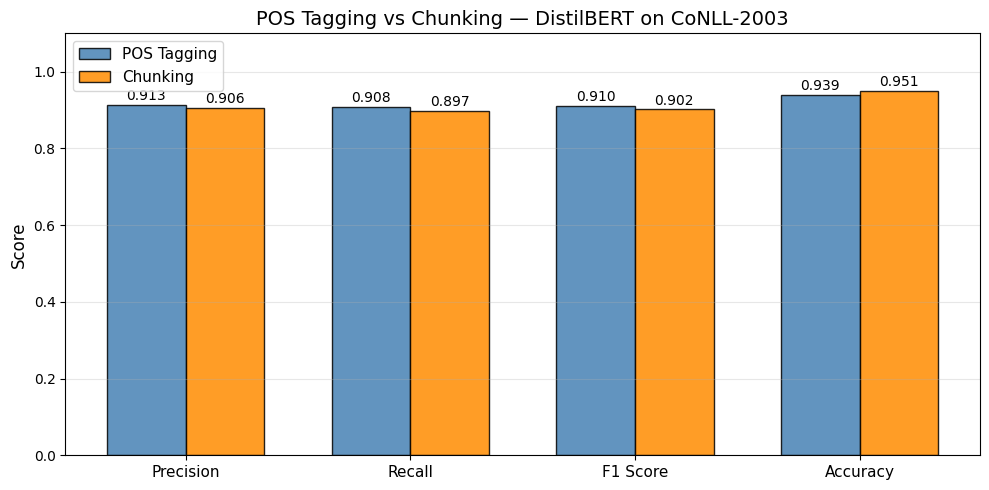

In [16]:
# ── Visual Comparison ─────────────────────────────────────
metrics    = ['Precision', 'Recall', 'F1 Score', 'Accuracy']
pos_vals   = [results_pos['eval_precision'],   results_pos['eval_recall'],
              results_pos['eval_f1'],           results_pos['eval_accuracy']]
chunk_vals = [results_chunk['eval_precision'], results_chunk['eval_recall'],
              results_chunk['eval_f1'],         results_chunk['eval_accuracy']]

x     = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
bars1 = ax.bar(x - width/2, pos_vals,   width, label='POS Tagging',
               color='steelblue', edgecolor='black', alpha=0.85)
bars2 = ax.bar(x + width/2, chunk_vals, width, label='Chunking',
               color='darkorange', edgecolor='black', alpha=0.85)

for bar in list(bars1) + list(bars2):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=10)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.1)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('POS Tagging vs Chunking — DistilBERT on CoNLL-2003', fontsize=14)
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('pos_vs_chunking_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

In [17]:
# ── Per-class breakdown for POS ────────────────────────────
print("📊 Per-class seqeval results are computed internally by the Trainer.")
print("   Overall results summary printed above.")
print(f"\n✅ POS Tagging  — F1: {results_pos['eval_f1']:.4f}")
print(f"✅ Chunking     — F1: {results_chunk['eval_f1']:.4f}")
print("\n📌 Both models trained on CoNLL-2003 using DistilBERT + HuggingFace Trainer + seqeval")

📊 Per-class seqeval results are computed internally by the Trainer.
   Overall results summary printed above.

✅ POS Tagging  — F1: 0.9102
✅ Chunking     — F1: 0.9015

📌 Both models trained on CoNLL-2003 using DistilBERT + HuggingFace Trainer + seqeval
